# Access the analysis ready satellite ocean colour data

This notebook provides an example of how to open the satellite-ocean-colour Zarr store using xarray.
You will need to insert your CDS API key where indicated in the following code cell (available on [your profile page](https://cds.climate.copernicus.eu/profile)).
For more information on using the Data Store Analysis Ready Datasets, please see the [user documentation pages](https://cds.climate.copernicus.eu/datasets/how-to-use-the-dss-arco-dataset).

In [1]:
import os
cdsapi_key = "<INSERT-CDS-API-KEY-HERE>"

# The following attempts to find the CDSAPI key in your environment.
if cdsapi_key == "<INSERT-CDS-API-KEY-HERE>":
    cdsapi_key = None
if cdsapi_key is None:
    cdsapi_key = os.getenv("CDSAPI_KEY")
if cdsapi_key is None and os.path.exists(os.path.expanduser("~/.cdsapirc")):
    with open(os.path.expanduser("~/.cdsapirc"), "r") as f:
        for line in f:
            if line.startswith("key:"):
                cdsapi_key = line.split(":")[1].strip()
                break
if cdsapi_key is None:
    raise ValueError("CDSAPI key not found. Please set the CDSAPI_KEY environment variable or create a ~/.cdsapirc file.")


## Plug and play access

The code below provides a simple plug and play example of how to use the Zarr Store for light-weight access.

In [2]:
import xarray as xr

# Time-chunked data (optimised for global map at a single time step)
timechunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-044/arco/satellite_ocean_colour/all/timeChunked.zarr"

# Geo-chunked data (optimised for time-series at a single location)
geochunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-044/arco/satellite_ocean_colour/all/geoChunked.zarr"


# Open the zarr store with xarray, users must insert their API key where indicated.
ds = xr.open_zarr(
    timechunked_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 21TB
Dimensions:       (time: 9981, latitude: 4320, longitude: 8640)
Coordinates:
  * time          (time) datetime64[ns] 80kB 1997-09-04 ... 2024-12-31
  * latitude      (latitude) float64 35kB -89.98 -89.94 -89.9 ... 89.94 89.98
  * longitude     (longitude) float64 69kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables: (12/14)
    total_nobs    (time, latitude, longitude) float32 1TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    MERIS_nobs    (time, latitude, longitude) float32 1TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    MODISA_nobs   (time, latitude, longitude) float32 1TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    OLCI-A_nobs   (time, latitude, longitude) float32 1TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    OLCI-B_nobs   (time, latitude, longitude) float32 1TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    Rrs_412       (time, latitude, longitude) float32 1TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    ...            ...
    Rrs_510       (time, latitude, longitude) float32 1TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    Rrs_560       (time, latitude, longitude) float32 1TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    Rrs_665       (time, latitude, longitude) float32 1TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    SeaWiFS_nobs  (time, latitude, longitude) float32 1TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    VIIRS_nobs    (time, latitude, longitude) float32 1TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    chlor_a       (time, latitude, longitude) float32 1TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>

Plot a global map of remote sensing reflectance at 412nm using earthkit-plots.

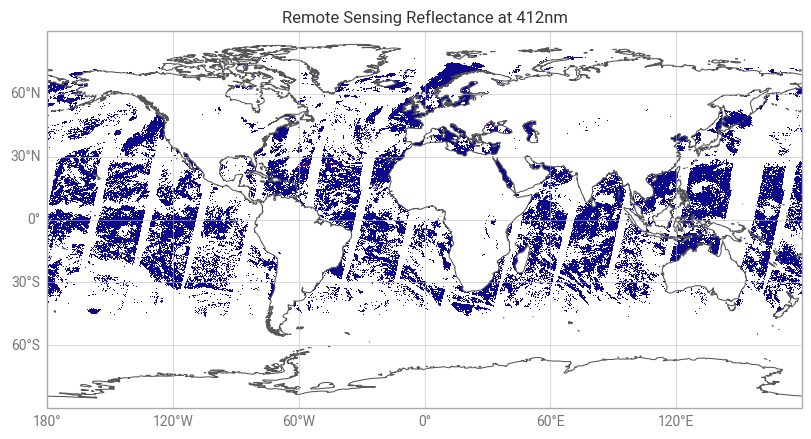

In [3]:
from earthkit import plots as ekp

# Select a single time step to plot
plot_data = ds["Rrs_412"].sel(time="2020-06-01", method="nearest")

chart = ekp.Map()

chart.grid_cells(plot_data)

chart.coastlines()
chart.gridlines()

chart.title("Remote Sensing Reflectance at 412nm")

chart.show()

## Advanced usage

If your workflow requires access to larger amounts of data, it is recommended that you include a retry mechanism.
This is not provided in the current default zarr engine for xarray, instead we can define a custom "`store`" which is
used when connecting to the remote zarr data.

In [4]:
!pip install -q obstore
import xarray as xr
from obstore.store import HTTPStore
from zarr.storage import ObjectStore

# Time-chunked data (optimised for global map at a single time step)
timechunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-044/arco/satellite_ocean_colour/all/timeChunked.zarr"

# Geo-chunked data (optimised for time-series at a single location)
geochunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-044/arco/satellite_ocean_colour/all/geoChunked.zarr"


# Use obstore's HTTPStore to create a store with retry configuration,
# and then wrap it in a zarr ObjectStore to read with xarray.
# See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# for more details on the retry configuration options.
http_store = HTTPStore(
    geochunked_url,
    client_options={
        "default_headers": {"Authorization": f"Bearer {cdsapi_key}"},
    },
)
store = ObjectStore(http_store, read_only=True)
ds = xr.open_zarr(store)
ds

<xarray.Dataset> Size: 21TB
Dimensions:       (time: 9981, latitude: 4320, longitude: 8640)
Coordinates:
  * time          (time) datetime64[ns] 80kB 1997-09-04 ... 2024-12-31
  * latitude      (latitude) float64 35kB -89.98 -89.94 -89.9 ... 89.94 89.98
  * longitude     (longitude) float64 69kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables: (12/14)
    total_nobs    (time, latitude, longitude) float32 1TB dask.array<chunksize=(2112, 16, 32), meta=np.ndarray>
    MERIS_nobs    (time, latitude, longitude) float32 1TB dask.array<chunksize=(2112, 16, 32), meta=np.ndarray>
    MODISA_nobs   (time, latitude, longitude) float32 1TB dask.array<chunksize=(2112, 16, 32), meta=np.ndarray>
    OLCI-A_nobs   (time, latitude, longitude) float32 1TB dask.array<chunksize=(2112, 16, 32), meta=np.ndarray>
    OLCI-B_nobs   (time, latitude, longitude) float32 1TB dask.array<chunksize=(2112, 16, 32), meta=np.ndarray>
    Rrs_412       (time, latitude, longitude) float32 1TB dask.array<chunksize=(2112, 16, 32), meta=np.ndarray>
    ...            ...
    Rrs_510       (time, latitude, longitude) float32 1TB dask.array<chunksize=(2112, 16, 32), meta=np.ndarray>
    Rrs_560       (time, latitude, longitude) float32 1TB dask.array<chunksize=(2112, 16, 32), meta=np.ndarray>
    Rrs_665       (time, latitude, longitude) float32 1TB dask.array<chunksize=(2112, 16, 32), meta=np.ndarray>
    SeaWiFS_nobs  (time, latitude, longitude) float32 1TB dask.array<chunksize=(2112, 16, 32), meta=np.ndarray>
    VIIRS_nobs    (time, latitude, longitude) float32 1TB dask.array<chunksize=(2112, 16, 32), meta=np.ndarray>
    chlor_a       (time, latitude, longitude) float32 1TB dask.array<chunksize=(2112, 16, 32), meta=np.ndarray>

The result is the same as the previous example, this just provides a more robust connection, preventing your
workflow crashing due to temporary network issues.